<a href="https://colab.research.google.com/github/Chirag240105/Machine_Learning/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# STEP 2: Upload kaggle.json API key
from google.colab import files
files.upload()

# STEP 3: Setup Kaggle API key
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json



Saving kaggle.json to kaggle.json


In [3]:
import os

# STEP 4: Download the dataset
!kaggle datasets download -d mlg-ulb/creditcardfraud

# STEP 5: Unzip the downloaded file
!unzip creditcardfraud.zip

# Verify the extracted files
print('Extracted files:')
!ls -F


Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 73.4MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          
Extracted files:
creditcard.csv	creditcardfraud.zip  kaggle.json  sample_data/


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    ConfusionMatrixDisplay)


In [5]:
df = pd.read_csv('creditcard.csv')

# Data Understanding

In [6]:
def Report(Data_file):
  print("Random first 10 sample :: \n", Data_file.sample(10))
  print("\n---------------- Line Break ----------------\n")
  print("Data Shape :: \n", Data_file.shape)
  print("\n---------------- Line Break ----------------\n")
  print("Data description :: \n", Data_file.describe())
  print("\n---------------- Line Break ----------------\n")
  print("Data Info :: \n", Data_file.info())
  print("\n---------------- Line Break ----------------\n")
  print("Null_Values in Data :: \n", Data_file.isnull().sum())
  print("\n---------------- Line Break ----------------\n")
  print("Columns in data :: \n", Data_file.columns)
  print("\n---------------- Line Break ----------------\n")
  print("Class values distribution :: \n", Data_file['Class'].value_counts())

In [7]:
Report(df)

Random first 10 sample :: 
             Time        V1        V2        V3        V4        V5        V6  \
31399    36348.0  0.979861 -0.727305  1.010916  0.347188 -1.307217 -0.345054   
208245  137035.0  1.957778 -0.229079 -0.896589  0.124183 -0.274162 -0.228216   
158504  111352.0 -1.664155  0.206668  0.848287 -2.322733  1.573167  0.284148   
216802  140639.0 -1.960864  3.335156 -0.725020  4.361686 -0.606933  0.243661   
68086    52825.0 -3.057433  2.750293 -0.026552 -1.949093 -0.607848 -0.631236   
22863    32476.0  1.411806 -1.617902  1.288061 -1.091561 -1.846719  1.135466   
196156  131379.0  2.100786 -0.075406 -1.640811 -0.073050  0.787463  0.173578   
190436  128835.0  1.574903 -0.570251  1.222836  4.353759 -1.169722  1.396883   
177280  123112.0 -1.611292  0.695670  0.412745 -1.111688  1.220988  0.945053   
278635  168329.0 -1.317972 -0.035978  1.588789 -0.650735  0.066160 -0.259651   

              V7        V8        V9  ...       V21       V22       V23  \
31399  -0.482741

# EDA -> Exploratory Data Analysis

In [8]:
normal_transactions = df[df['Class'] == 0]
fraud_transactions = df[df['Class'] == 1]

In [9]:
def eda(Data_file):
  print("Duplicate rows :: ", Data_file.duplicated().sum())
  print("\n----------------Line break---------------\n")
  print("Duplicate columns :: ", Data_file.columns.duplicated().sum())
  print("\n----------------Line break---------------\n")
  print("Skew :: ", Data_file.skew())
  print("\n----------------Line break---------------\n")
  print("Qunatile :: ", Data_file.quantile([0.25, 0.50, 0.75]))
  print("\n----------------Line break---------------\n")
  print("Count Plot visualization :: ", sns.countplot(x='Class', data=Data_file))
  print("\n----------------Line break---------------\n")
  print("Mean of amount :: ", Data_file['Amount'].mean)
  print("\n----------------Line break---------------\n")
  print("Visualisation diagram ::: " )
  plt.figure(figsize=(10, 5)),
  plt.hist(
          normal_transactions['Amount'],
          bins=50,
          alpha=0.5,
          color='green',
          label='Normal'
      )
  plt.hist(
          fraud_transactions['Amount'],
          bins=50,
          alpha=0.5,
          color='red',
          label='Fraud'
      )

  plt.xlim(0,2000)
  plt.xlabel("Transaction amount")
  plt.ylabel("Frequency")
  plt.title("Transaction amount distribution")
  plt.legend()
  plt.show()
  print("\n----------------Line break---------------\n")

Duplicate rows ::  1081

----------------Line break---------------

Duplicate columns ::  0

----------------Line break---------------

Skew ::  Time      -0.035568
V1        -3.280667
V2        -4.624866
V3        -2.240155
V4         0.676292
V5        -2.425901
V6         1.826581
V7         2.553907
V8        -8.521944
V9         0.554680
V10        1.187141
V11        0.356506
V12       -2.278401
V13        0.065233
V14       -1.995176
V15       -0.308423
V16       -1.100966
V17       -3.844914
V18       -0.259880
V19        0.109192
V20       -2.037155
V21        3.592991
V22       -0.213258
V23       -5.875140
V24       -0.552499
V25       -0.415793
V26        0.576693
V27       -1.170209
V28       11.192091
Amount    16.977724
Class     23.997579
dtype: float64

----------------Line break---------------

Qunatile ::            Time        V1        V2        V3        V4        V5        V6  \
0.25   54201.5 -0.920373 -0.598550 -0.890365 -0.848640 -0.691597 -0.768296   
0.50   

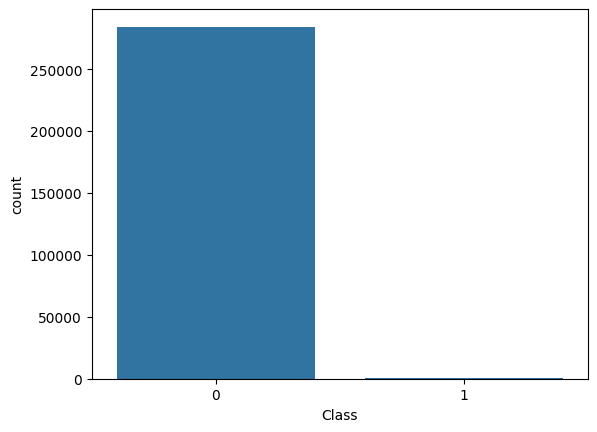

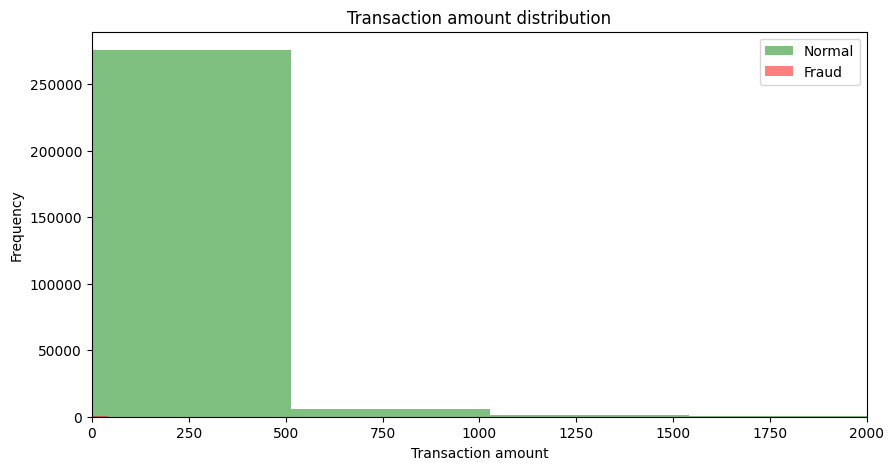


----------------Line break---------------



In [10]:
eda(df)

# Data Processing
*Missing values || Encoding || Scaling || Outlier Treatment || Class balancing*

In [11]:
df.drop_duplicates(inplace=True)

# feature Engineering

In [31]:
df['hour'] = (df['Time'] % (24 * 3600)) // 3600

## Splitting Data in x and y

In [32]:
X = df.drop('Class', axis=1)
y = df['Class']
print(X.shape)
print(y.shape)

(283726, 31)
(283726,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.3,
    stratify=y,
    random_state=42
)


In [34]:
y_train.head()

,Class
257334,0
118498,0
120679,0
163000,0
171948,0


In [35]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[['hour', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test_scaled[['hour', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']]) # only transform because scaler already learned every thing (mean , deviation )so no need to do fit_transform()

In [36]:
print(scaler.mean_)

[9.49158742e+04 8.83216792e+01]


In [37]:
def evaluate_model(model, y_true, y_pred):
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred, zero_division=0)
  f1 = f1_score(y_true, y_pred, zero_division=0)

  print("Model : ", model)
  print("_" * 50)
  print(f"Accuracy : {accuracy:.4f}")
  print(f"Precision : {precision:.4f}")
  print(f"Recall : {recall:.4f}")
  print(f"F1 Score : {f1:.4f}")

  print("\nClassofication Report : ")
  print(classification_report(y_true, y_pred))

  cm = confusion_matrix(y_true, y_pred)

  display = ConfusionMatrixDisplay(
      confusion_matrix= cm,
      display_labels = ['Normal', 'Fraud']
  )

  display.plot()
  plt.title(f"Confusion Matrix: {model}")
  plt.show()

  return {
      "Model": model,
      "Accuracy": accuracy,
      "Precision": precision,
      "Recall": recall,
      "F1 Score": f1
  }

In [38]:
from sklearn.linear_model import LogisticRegression
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
baseline_model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

## As you can see prediction = 99% because normal trasactions are more than fraud.
 results => large accuracy

Model :  Logistic regression
__________________________________________________
Accuracy : 0.9991
Precision : 0.8602
Recall : 0.5634
F1 Score : 0.6809

Classofication Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.86      0.56      0.68       142

    accuracy                           1.00     85118
   macro avg       0.93      0.78      0.84     85118
weighted avg       1.00      1.00      1.00     85118



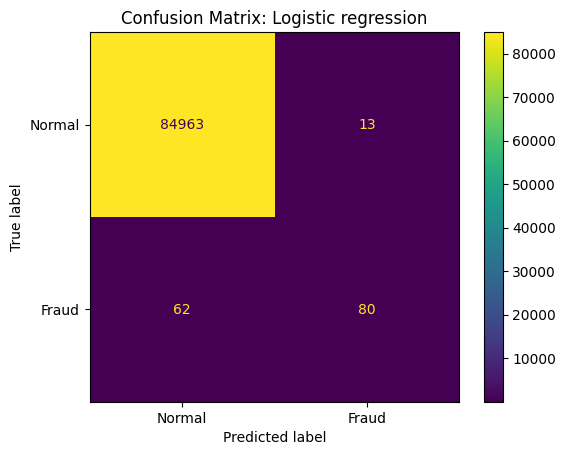

In [39]:
baseline_model_pred = baseline_model.predict(X_test_scaled)

baseline_result = evaluate_model(
    "Logistic regression",
    y_test,
    baseline_model_pred
)

# SMOTE

Make artificial fraud samples

In [45]:
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [46]:
print(y_train_smote.value_counts())

Class
0    198277
1    198277
Name: count, dtype: int64


In [47]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    n_jobs=-1
           )

rf.fit(x_train_smote, y_train_smote)


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [43]:
y_pred = rf.predict(X_test)

Model :  Random Forest SMOTE
__________________________________________________
Accuracy : 0.9995
Precision : 0.8880
Recall : 0.7817
F1 Score : 0.8315

Classofication Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.89      0.78      0.83       142

    accuracy                           1.00     85118
   macro avg       0.94      0.89      0.92     85118
weighted avg       1.00      1.00      1.00     85118



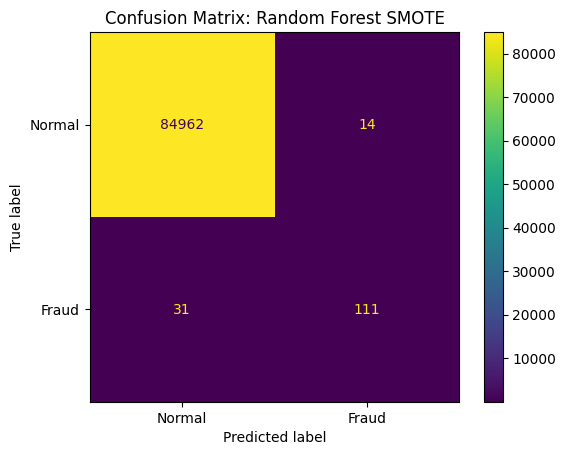

In [44]:
cm = evaluate_model("Random Forest SMOTE", y_test, y_pred)

In [48]:
# Example: one new transaction
new_transaction = {
    "Time": 50000,
    "V1": -1.2,
    "V2": 0.5,
    "V3": 1.1,
    "V4": -0.3,
    "V5": 0.2,
    "V6": -0.7,
    "V7": 0.4,
    "V8": 0.1,
    "V9": -0.5,
    "V10": 0.3,
    "V11": -0.8,
    "V12": 0.6,
    "V13": 0.2,
    "V14": -0.4,
    "V15": 0.7,
    "V16": -0.1,
    "V17": 0.5,
    "V18": -0.3,
    "V19": 0.2,
    "V20": 0.1,
    "V21": -0.2,
    "V22": 0.3,
    "V23": -0.1,
    "V24": 0.4,
    "V25": -0.2,
    "V26": 0.1,
    "V27": 0.05,
    "V28": -0.03,
    "Amount": 250.0
}

new_df = pd.DataFrame([new_transaction])

In [52]:
new_df_scaled = new_df.copy()
# Create the 'hour' column in new_df_scaled to maintain feature consistency with training data.
# Initially, this 'hour' column will hold the unscaled hour from 'Time'.
new_df_scaled['hour'] = (new_df_scaled['Time'] % (24 * 3600)) // 3600

# Scale the 'Time' and 'Amount' columns using the fitted scaler.
# The first output of scaler.transform (scaled 'Time') will be assigned to 'hour',
# and the second output (scaled 'Amount') will be assigned to 'Amount' in new_df_scaled.
new_df_scaled[['hour', 'Amount']] = scaler.transform(
    new_df_scaled[['Time', 'Amount']]
)

In [53]:
prediction = rf.predict(new_df_scaled)

print(prediction)

[0]


In [54]:
prediction = rf.predict(new_df_scaled)[0]
fraud_probability = rf.predict_proba(new_df_scaled)[0][1]

print("Prediction:", prediction)
print(f"Fraud probability: {fraud_probability:.2%}")

if prediction == 1:
    print("⚠️ FRAUD TRANSACTION")
else:
    print("✅ NORMAL TRANSACTION")

Prediction: 0
Fraud probability: 0.00%
✅ NORMAL TRANSACTION
